# Initial test of loading cropping and manipulating videos from Tim's data

In [94]:
import json
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchcodec.decoders import VideoDecoder
from torchvision.transforms import v2

In [2]:
video_path = '/home/kurgyis/Research/VideoAnalysisTools/data/kd115_side_trial111_date_2022_12_06_time_12_32_50.mp4'

In [3]:
decoder = VideoDecoder(video_path)

In [4]:
len(decoder)

2188

In [5]:
raw_frame = decoder.get_frame_at(174)

In [6]:
raw_frame

Frame:
  data (shape): torch.Size([3, 380, 464])
  pts_seconds: 174.0
  duration_seconds: 1.0

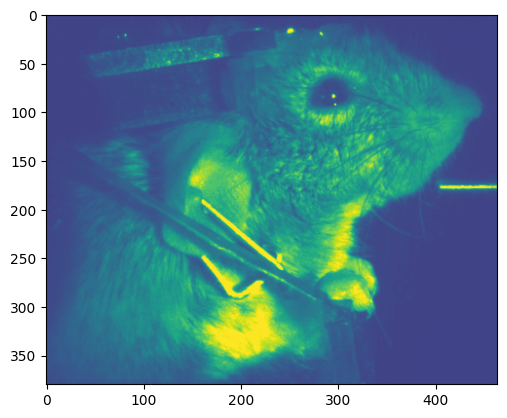

In [7]:
raw_img = raw_frame.data.permute(1, 2, 0).numpy()
plt.imshow(raw_img[:,:,0])

In [8]:
raw_img[:,:,0] - raw_img[:,:,1]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(380, 464), dtype=uint8)

In [9]:
raw_img.shape

(380, 464, 3)

In [10]:
# Let's design modular classes and functions for the dataloader and transformations. 
# We'll use a config file to set up the data path, cropping, resolution, and model architecture details.

In [11]:
config_path = '../configs/ae_config.json'
with open(config_path, 'r') as f:
    config = json.load(f)
print("Config loaded:", json.dumps(config, indent=2))

Config loaded: {
  "data": {
    "data_path": "/home/kurgyis/Research/VideoAnalysisTools/data/kd115_twNew_20221206_115814/side",
    "image_height": 120,
    "image_width": 112,
    "crop_top": 0,
    "crop_bottom": 80,
    "crop_left": 100,
    "crop_right": 0
  },
  "model": {
    "num_blocks": 2,
    "in_channels_0": 1,
    "out_channels_0": 16,
    "in_channels_1": 16,
    "out_channels_1": 32,
    "kernel_preconv": 3,
    "stride_preconv": 1,
    "pool_size_preconv_0": 2,
    "pool_size_preconv_1": 4,
    "use_batch_norm_preconv": false,
    "kernel_residual": 3,
    "stride_residual": 1,
    "use_batch_norm_residual": false,
    "pool_size_residual_0": null,
    "pool_size_residual_1": 4,
    "n_layers_residual": 3,
    "out_conv": 288,
    "out_linear": 128,
    "embed_size": 16,
    "use_batch_norm_linear": false,
    "image_height": 120,
    "image_width": 112
  },
  "training": {
    "batch_size": 32,
    "learning_rate": 0.001,
    "checkpoint_dir": "./checkpoints"
  }
}


In [12]:
def get_video_transforms(config):
    """
    Creates a torchvision v2 transform pipeline based on the config.
    It expects a tensor of shape (C, H, W) or (T, C, H, W) and returns a transformed tensor.
    """
    data_cfg = config['data']
    target_height = data_cfg.get('image_height', 120)
    target_width = data_cfg.get('image_width', 112)
    
    crop_top = data_cfg.get('crop_top', 0)
    crop_bottom = data_cfg.get('crop_bottom', 0)
    crop_left = data_cfg.get('crop_left', 0)
    crop_right = data_cfg.get('crop_right', 0)
    
    transforms_list = []
    
    # Optional cropping step
    # Note: v2.Lambda or custom module to handle dynamic cropping if it's dynamic
    # But for a fixed crop, v2.Lambda is simple.
    if crop_top > 0 or crop_bottom > 0 or crop_left > 0 or crop_right > 0:
        transforms_list.append(v2.Lambda(lambda x: x[..., crop_top:(x.shape[-2]-crop_bottom), crop_left:(x.shape[-1]-crop_right)]))
    
    # Resize step
    transforms_list.append(v2.Resize(size=(target_height, target_width), antialias=True))
    
    # Normalize step: to float [0, 1] if not already
    transforms_list.append(v2.ToDtype(torch.float32, scale=True))
    
    # We could add an optional Grayscale step if required
    # transforms_list.append(v2.Grayscale(num_output_channels=1))

    return v2.Compose(transforms_list)

transforms = get_video_transforms(config)
transforms

Compose(
      Lambda(<lambda>, types=['object'])
      Resize(size=[120, 112], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToDtype(scale=True)
)

Found 222 videos. Building frame index...
Index built. Total frames available: 49444
Sample frame shape: torch.Size([1, 120, 112])


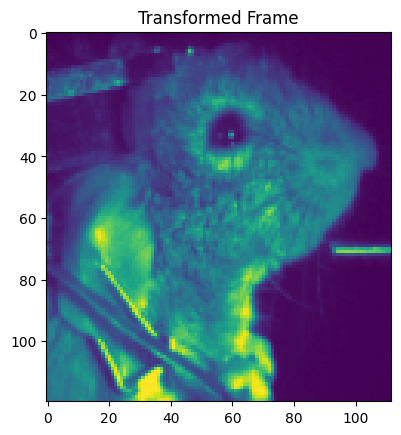

In [13]:
import os
import glob
from torch.utils.data import Dataset, DataLoader
from torchcodec.decoders import VideoDecoder

class SessionVideoDataset(Dataset):
    """
    A Dataset for loading frames from MP4 videos organized in session folders.
    Directory structure expected: data_path / session_folder / trial_video.mp4
    """
    def __init__(self, data_path, transform=None, frame_stride=1):
        self.data_path = data_path
        self.transform = transform
        self.frame_stride = frame_stride  # Sample every Nth frame
        
        self.video_files = []
        # Find all MP4 files in session subfolders or directly in data_path
        for root, _, files in os.walk(data_path):
            for file in files:
                if file.endswith('.mp4'):
                    self.video_files.append(os.path.join(root, file))
        
        self.video_files.sort()
        
        # State logic for caching decoders safely across DataLoader workers (multiprocessing)
        self._cache_pid = os.getpid()
        self._decoder_cache = {}
        
        # Build an index to map a global index to (video_file_index, frame_index)
        self.frame_index_map = []
        self._build_index()

    def _build_index(self):
        print(f"Found {len(self.video_files)} videos. Building frame index...")
        for vid_idx, vid_path in enumerate(self.video_files):
            try:
                # Do NOT use caching here, let it open normally to just get metadata lengths
                decoder = VideoDecoder(vid_path)
                num_frames = len(decoder)
                for frame_idx in range(0, num_frames, self.frame_stride):
                    self.frame_index_map.append((vid_idx, frame_idx))
            except Exception as e:
                print(f"Failed to load video {vid_path}: {e}")
        print(f"Index built. Total frames available: {len(self.frame_index_map)}")

    def _get_decoder(self, vid_path):
        """
        Cache VideoDecoders so we don't re-initialize the FFmpeg context every fetch.
        Using a custom cache tracked by PID so worker processes created by DataLoader 
        don't try to share corrupted file-pointers/contexts inherited from the main process.
        """
        current_pid = os.getpid()
        if current_pid != self._cache_pid:
            # Fork detected: Empty cache mapping to drop broken decoders.
            self._decoder_cache.clear()
            self._cache_pid = current_pid
            
        if vid_path not in self._decoder_cache:
            if len(self._decoder_cache) >= 256:
                # Remove an arbitrary oldest item if we exceed cache size
                self._decoder_cache.pop(next(iter(self._decoder_cache)))
            self._decoder_cache[vid_path] = VideoDecoder(vid_path)
            
        return self._decoder_cache[vid_path]

    def __len__(self):
        return len(self.frame_index_map)
    
    def __getitem__(self, idx):
        vid_idx, frame_idx = self.frame_index_map[idx]
        vid_path = self.video_files[vid_idx]
        
        # Load the specific frame using our PID-safe cache
        decoder = self._get_decoder(vid_path)
        # .data returns shape (C, H, W) for torchcodec
        # We just grab the first channel (index 0) and keep the dimension
        frame_tensor = decoder.get_frame_at(frame_idx).data[0:1, :, :]
        
        if self.transform:
            frame_tensor = self.transform(frame_tensor)
            
        return frame_tensor

# Test the Dataset
dataset = SessionVideoDataset(data_path=config['data']['data_path'], transform=transforms, frame_stride=10)
if len(dataset) > 0:
    sample_frame = dataset[0]
    print(f"Sample frame shape: {sample_frame.shape}")
    plt.imshow(sample_frame.permute(1, 2, 0).numpy())
    plt.title("Transformed Frame")
    plt.show()

In [14]:
dataset[0].shape

torch.Size([1, 120, 112])

In [15]:
# Create the DataLoader
batch_size = config['training'].get('batch_size', 32)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# Test DataLoader
if len(dataset) > 0:
    for batch in dataloader:
        print(f"Batch shape: {batch.shape}")
        break

Batch shape: torch.Size([32, 1, 120, 112])


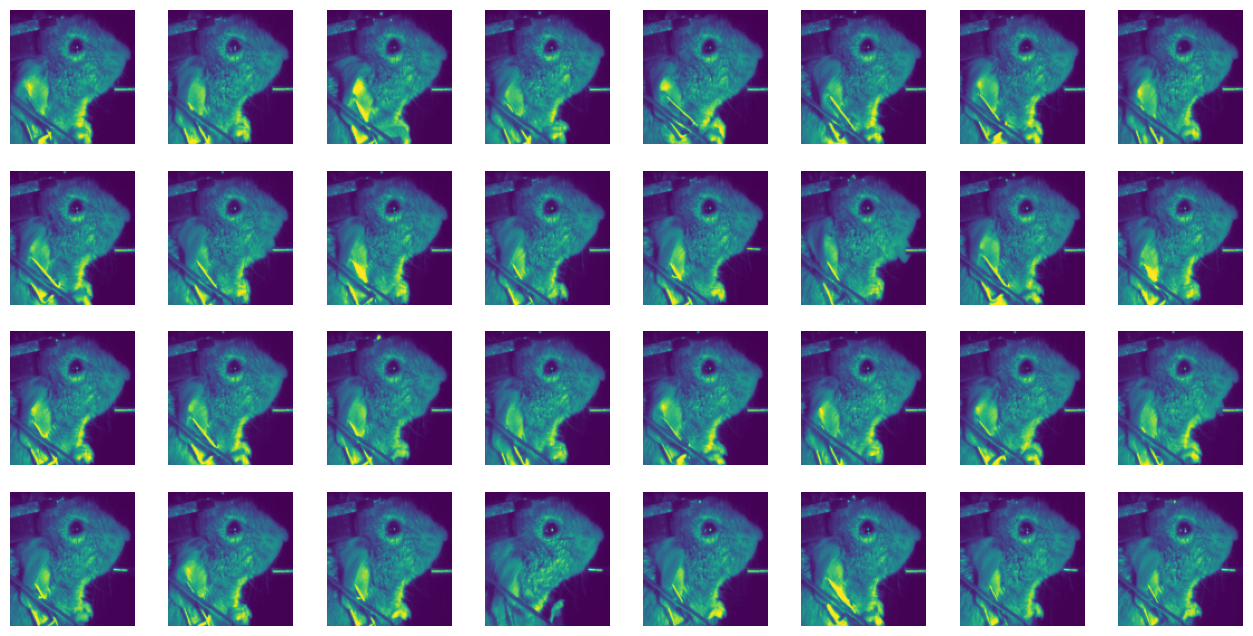

In [16]:
plt.subplots(4,8, figsize=(16,8))
for i in range(32):
    plt.subplot(4, 8, i+1)
    plt.axis('off')
    plt.imshow(batch[i].permute(1, 2, 0).numpy())

In [14]:
import sys
sys.path.append('/home/kurgyis/Research/VideoAnalysisTools/src/')
from behavioral_autoencoder.models import AutoEncoder

In [15]:
ae = AutoEncoder(config['model'])

In [16]:
import torch.nn as nn

In [24]:
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)

loss_fn = nn.MSELoss()

n_epochs = 1000

for epoch in range(n_epochs):
    optimizer.zero_grad()
    x_hat, z = ae.forward(torch.tensor(batch).float().view(32,1,1,120,112))
    loss = loss_fn(x_hat.squeeze(), batch.squeeze())
    loss.backward()
    optimizer.step()
    if epoch%100 == 99: print(epoch, loss.item())

/tmp/ipykernel_23973/3892847415.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_hat, z = ae.forward(torch.tensor(batch).float().view(32,1,1,120,112))


99 0.0061288196593523026
199 0.004092615097761154
299 0.004051936790347099
399 0.004046422429382801
499 0.004043058957904577
599 0.004040967207401991
699 0.004048729315400124
799 0.004037837032228708
899 0.004043095745146275
999 0.004035367164760828


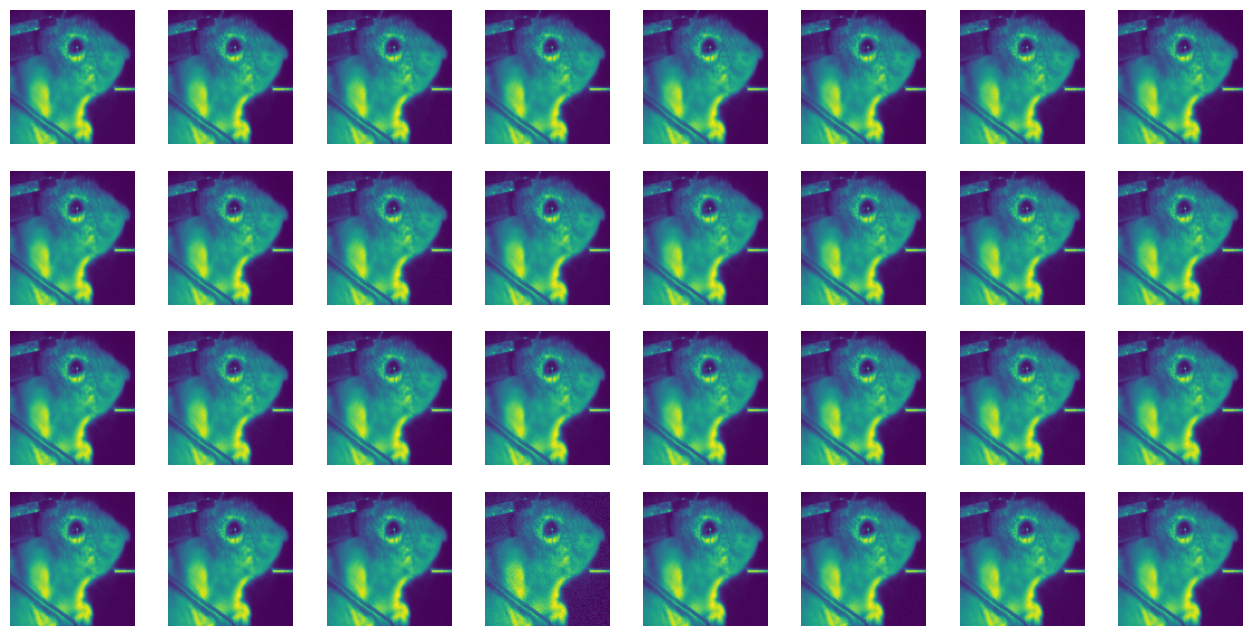

In [26]:
plt.subplots(4,8, figsize=(16,8))
for i in range(32):
    plt.subplot(4, 8, i+1)
    plt.axis('off')
    plt.imshow(x_hat[i].squeeze().detach().numpy())

In [28]:


# Compute the mean image out of the entire dataloader
# We'll accumulate the pixel values and divide by the total number of frames grabbed
mean_image = None
total_frames = 0

print("Computing mean frame across the session...")
for batch in (dataloader):
    # batch shape is (B, C, H, W)
    if mean_image is None:
        mean_image = torch.zeros_like(batch[0], dtype=torch.float64)
        
    mean_image += batch.sum(dim=0).to(torch.float64)
    total_frames += batch.size(0)

mean_image = (mean_image / total_frames).to(torch.float32)

print(f"Mean image calculated over {total_frames} frames. Shape: {mean_image.shape}")

plt.figure(figsize=(6,6))
plt.imshow(mean_image.permute(1, 2, 0).numpy())
plt.title("Session Mean Image")
plt.axis('off')
plt.show()

Computing mean frame across the session...


KeyboardInterrupt: 

In [30]:
for i in range(10):
    batch = next(iter(dataloader))
    

In [19]:
import h5py
import re
from tqdm import tqdm

def convert_videos_to_hdf5(video_folder, h5_filename="session_data.h5", save_path=None, transform=None):
    """
    Sequentially processes all MP4 files in a folder, extracts each frame, applies transforms,
    and saves the frames along with the trial number, filename, and frame index within the trial into an HDF5 file.
    """
    if save_path is None:
        save_path = video_folder
    
    output_file = os.path.join(save_path, h5_filename)
    
    # Gather videos
    video_files = []
    for root, _, files in os.walk(video_folder):
        for file in files:
            if file.endswith('.mp4'):
                video_files.append(os.path.join(root, file))
    
    video_files.sort()
    
    if not video_files:
        print(f"No .mp4 files found in {video_folder}")
        return
    
    print(f"Found {len(video_files)} videos. Starting HDF5 conversion to {output_file}...")
    
    # We will use resizable datasets in HDF5 because we don't know the exact total frame count upfront uniformly
    with h5py.File(output_file, 'w') as f:
        # Create datasets with maxshape=None for dynamically resizing along the 0th (frame) dimension
        # Assuming transformed frames are (1, H, W)
        ds_frames = None
        ds_trial_ids = f.create_dataset("trial_ids", shape=(0,), maxshape=(None,), dtype='i')
        ds_id_within_trial = f.create_dataset("id_within_trial", shape=(0,), maxshape=(None,), dtype='i')
        dt_string = h5py.string_dtype(encoding='utf-8')
        ds_filenames = f.create_dataset("filenames", shape=(0,), maxshape=(None,), dtype=dt_string)
        
        current_frame_idx = 0
        
        for vid_path in tqdm(video_files, desc="Processing Videos"):
            
            # Extract trial number using regex e.g., "_trial111_" -> 111
            match = re.search(r'_trial(\d+)_', os.path.basename(vid_path))
            trial_id = int(match.group(1)) if match else -1
            
            filename_str = os.path.basename(vid_path)
            
            # Open Video sequentially
            decoder = VideoDecoder(vid_path)
            num_frames = len(decoder)
            
            for i in range(num_frames):
                # get single channel natively as requested
                frame_tensor = decoder.get_frame_at(i).data[0:1, :, :]
                
                # Apply transfrom if any (crop, resize, float normalization)
                if transform:
                    frame_tensor = transform(frame_tensor)
                
                numpy_frame = frame_tensor.numpy()
                
                # If first frame of the entire session, initialize the dataset shape based on transform output
                if ds_frames is None:
                    ch, h, w = numpy_frame.shape
                    ds_frames = f.create_dataset("frames", shape=(0, ch, h, w), maxshape=(None, ch, h, w), dtype='float32', compression="lzf")

                # Resize datasets to hold 1 more frame
                ds_frames.resize(current_frame_idx + 1, axis=0)
                ds_trial_ids.resize(current_frame_idx + 1, axis=0)
                ds_id_within_trial.resize(current_frame_idx + 1, axis=0)
                ds_filenames.resize(current_frame_idx + 1, axis=0)
                
                # Write to disk
                ds_frames[current_frame_idx] = numpy_frame
                ds_trial_ids[current_frame_idx] = trial_id
                ds_id_within_trial[current_frame_idx] = i  # Store the frame's index within this trial
                ds_filenames[current_frame_idx] = filename_str
                
                current_frame_idx += 1
                
    print(f"Done! Successfully packed {current_frame_idx} frames into {output_file}")

# Example to call the function:
# convert_videos_to_hdf5(video_folder=config['data']['data_path'], transform=transforms)

In [21]:
import h5py
import re
import os
import torch
import numpy as np
from tqdm import tqdm
from torchcodec.decoders import VideoDecoder

def convert_videos_to_hdf5(video_folder, h5_filename="session_data.h5", save_path=None, transform=None):
    """
    Sequentially processes all MP4 files in a folder, extracts each frame, applies transforms,
    and saves the frames along with the trial number, filename, and frame index within the trial into an HDF5 file.
    """
    if save_path is None:
        save_path = video_folder
    
    output_file = os.path.join(save_path, h5_filename)
    
    # Gather videos
    video_files = []
    for root, _, files in os.walk(video_folder):
        for file in files:
            if file.endswith('.mp4'):
                video_files.append(os.path.join(root, file))
    
    video_files.sort()
    
    if not video_files:
        print(f"No .mp4 files found in {video_folder}")
        return
    
    print(f"Found {len(video_files)} videos. Starting HDF5 conversion to {output_file}...")
    
    with h5py.File(output_file, 'w') as f:
        ds_frames = None
        
        # Initialize metadata datasets
        ds_trial_ids = f.create_dataset("trial_ids", shape=(0,), maxshape=(None,), dtype='i')
        ds_id_within_trial = f.create_dataset("id_within_trial", shape=(0,), maxshape=(None,), dtype='i')
        dt_string = h5py.string_dtype(encoding='utf-8')
        ds_filenames = f.create_dataset("filenames", shape=(0,), maxshape=(None,), dtype=dt_string)
        
        current_frame_idx = 0
        
        for vid_path in tqdm(video_files, desc="Processing Videos"):
            # Extract trial number using regex e.g., "_trial111_" -> 111
            match = re.search(r'_trial(\d+)_', os.path.basename(vid_path))
            trial_id = int(match.group(1)) if match else -1
            filename_str = os.path.basename(vid_path)
            
            decoder = VideoDecoder(vid_path)
            num_frames = len(decoder)
            
            if num_frames == 0:
                continue
                
            # --- OPTIMIZATION 1: Resize the dataset ONCE per video ---
            new_total_frames = current_frame_idx + num_frames
            
            # If this is the first video, peek at a frame to initialize the dataset shape
            if ds_frames is None:
                sample_frame = decoder.get_frame_at(0).data[0:1, :, :]
                if transform:
                    sample_frame = transform(sample_frame)
                ch, h, w = sample_frame.shape
                
                # OPTIMIZATION 2: Enforce uint8 and specify disk chunks
                ds_frames = f.create_dataset(
                    "frames", 
                    shape=(0, ch, h, w), 
                    maxshape=(None, ch, h, w), 
                    dtype='uint8',           # Enforce 1-byte per pixel
                    chunks=(256, ch, h, w),  # Chunk size optimized for read speed
                    compression="lzf"
                )

            # Resize datasets to hold the entire current video
            ds_frames.resize(new_total_frames, axis=0)
            ds_trial_ids.resize(new_total_frames, axis=0)
            ds_id_within_trial.resize(new_total_frames, axis=0)
            ds_filenames.resize(new_total_frames, axis=0)
            
            # --- OPTIMIZATION 3: Process frames and write into the pre-allocated slice ---
            for i in range(num_frames):
                frame_tensor = decoder.get_frame_at(i).data[0:1, :, :]
                
                if transform:
                    frame_tensor = transform(frame_tensor)
                
                # Safely handle float-to-uint8 conversion if your transform scales to [0.0, 1.0]
                if frame_tensor.is_floating_point():
                    if frame_tensor.max() <= 1.0:
                        frame_tensor = (frame_tensor * 255.0).clamp(0, 255)
                    frame_tensor = frame_tensor.to(torch.uint8)
                else:
                    frame_tensor = frame_tensor.to(torch.uint8)
                
                numpy_frame = frame_tensor.numpy()
                
                # Write directly to the pre-allocated index
                write_idx = current_frame_idx + i
                ds_frames[write_idx] = numpy_frame
                ds_trial_ids[write_idx] = trial_id
                ds_id_within_trial[write_idx] = i
                ds_filenames[write_idx] = filename_str
                
            current_frame_idx = new_total_frames
            
    print(f"Done! Successfully packed {current_frame_idx} frames into {output_file}")

# Example to call the function:
# convert_videos_to_hdf5(video_folder=config['data']['data_path'], transform=transforms)

In [22]:
convert_videos_to_hdf5(video_folder=config['data']['data_path'], transform=transforms,
                       h5_filename='kd115_twNew_20221206_115814_side.h5',
                       save_path = '/home/kurgyis/Research/VideoAnalysisTools/data/kd115_twNew_20221206_115814/')

Found 222 videos. Starting HDF5 conversion to /home/kurgyis/Research/VideoAnalysisTools/data/kd115_twNew_20221206_115814/kd115_twNew_20221206_115814_side.h5...


Exception ignored in: <function tqdm.__del__ at 0x7f47afbf2c00>
Traceback (most recent call last):
  File "/home/kurgyis/Research/VideoAnalysisTools/.venv/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/kurgyis/Research/VideoAnalysisTools/.venv/lib/python3.12/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Processing Videos: 100%|██████████| 222/222 [29:38<00:00,  8.01s/it]

Done! Successfully packed 493435 frames into /home/kurgyis/Research/VideoAnalysisTools/data/kd115_twNew_20221206_115814/kd115_twNew_20221206_115814_side.h5


In [45]:
import h5py
h5_session_path = '/home/kurgyis/Research/VideoAnalysisTools/data/kd115_twNew_20221206_115814/kd115_twNew_20221206_115814_side.h5'

dataset = h5py.File(h5_session_path, 'r')

In [16]:
dataset.keys()

<KeysViewHDF5 ['filenames', 'frames', 'id_within_trial', 'trial_ids']>

In [17]:
dataset['filenames'][:10]

array([b'kd115_side_trial101_date_2022_12_06_time_12_30_29.mp4',
       b'kd115_side_trial101_date_2022_12_06_time_12_30_29.mp4',
       b'kd115_side_trial101_date_2022_12_06_time_12_30_29.mp4',
       b'kd115_side_trial101_date_2022_12_06_time_12_30_29.mp4',
       b'kd115_side_trial101_date_2022_12_06_time_12_30_29.mp4',
       b'kd115_side_trial101_date_2022_12_06_time_12_30_29.mp4',
       b'kd115_side_trial101_date_2022_12_06_time_12_30_29.mp4',
       b'kd115_side_trial101_date_2022_12_06_time_12_30_29.mp4',
       b'kd115_side_trial101_date_2022_12_06_time_12_30_29.mp4',
       b'kd115_side_trial101_date_2022_12_06_time_12_30_29.mp4'],
      dtype=object)

In [18]:
dataset['trial_ids'][:10]

array([101, 101, 101, 101, 101, 101, 101, 101, 101, 101], dtype=int32)

In [19]:
dataset['id_within_trial'][:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)

In [20]:
random_inds = np.random.choice(len(dataset['frames']), size=32, replace=False)

batch = np.stack([dataset['frames'][i] for i in random_inds], axis=0)


In [21]:
batch = np.stack(dataset['frames'][np.sort(random_inds)], axis=0)

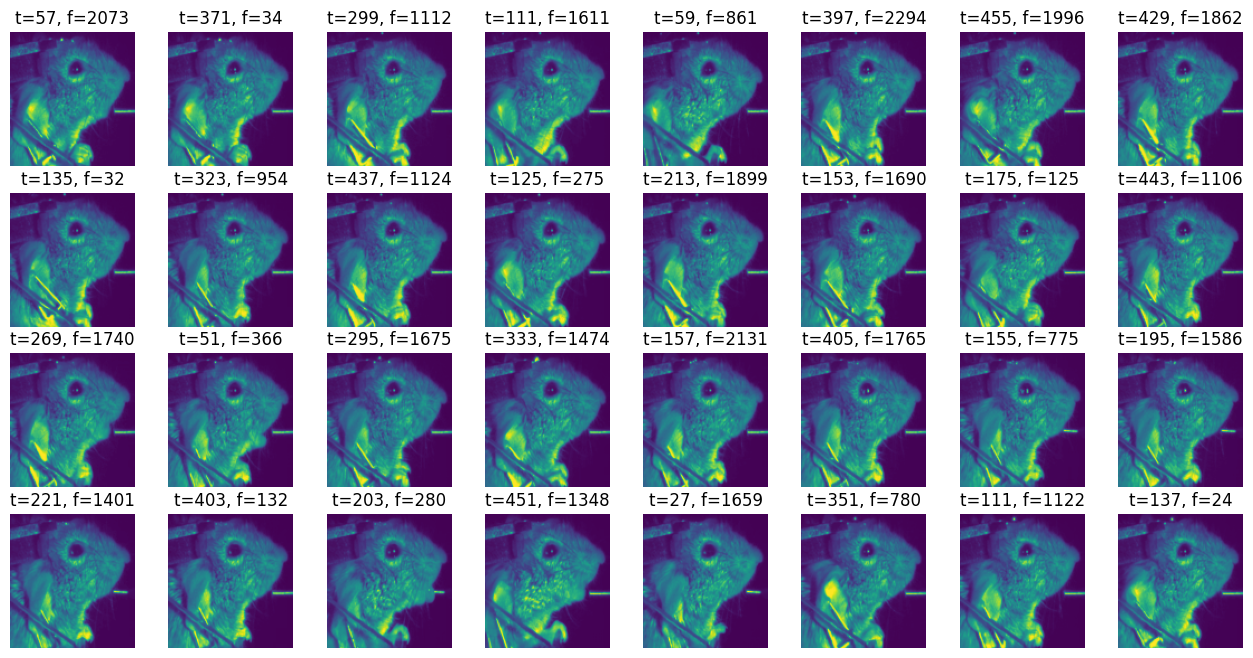

In [33]:
plt.subplots(4,8, figsize=(16,8))
for i in range(32):
    plt.subplot(4, 8, i+1)
    plt.axis('off')
    plt.imshow(batch[i][0])
    plt.title(f"t={dataset['trial_ids'][random_inds[i]]}, f={dataset['id_within_trial'][random_inds[i]]}")

In [25]:
mean_frame = dataset['frames'][:].mean(axis = 0 )

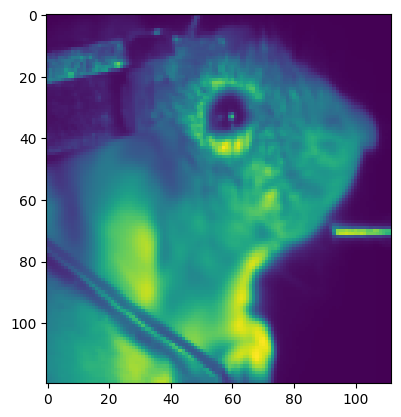

In [26]:
plt.imshow(mean_frame[0])

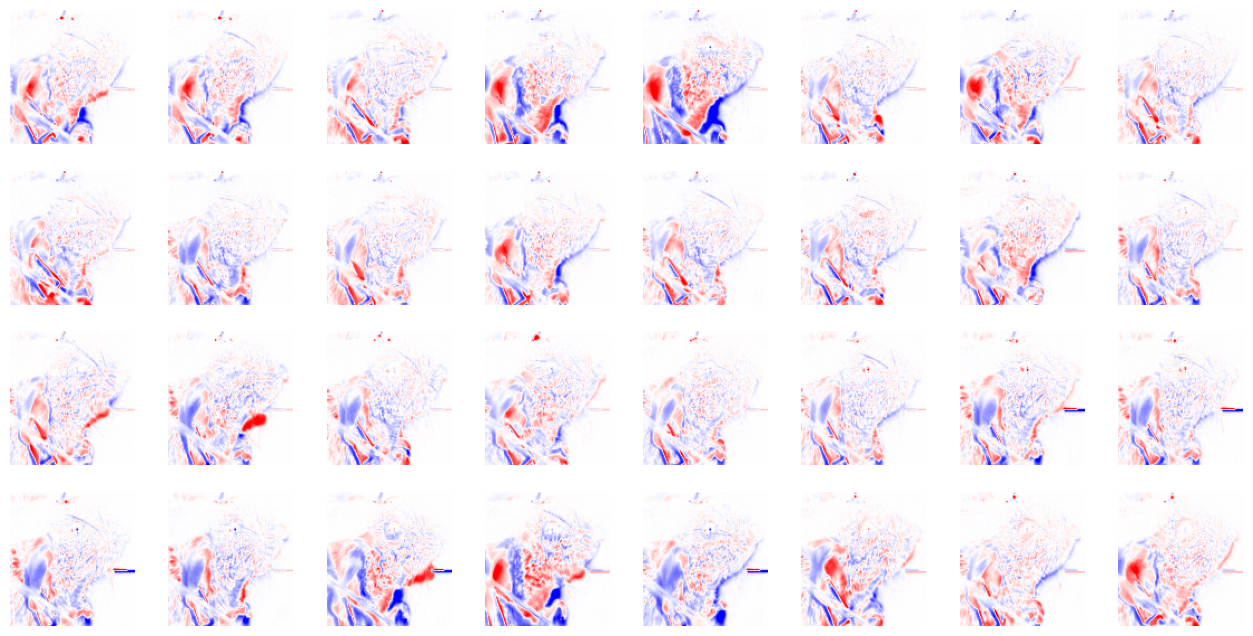

In [32]:
plt.subplots(4,8, figsize=(16,8))
for i in range(32):
    plt.subplot(4, 8, i+1)
    plt.axis('off')
    plt.imshow(batch[i][0] - mean_frame[0], cmap = 'bwr', vmin = -100, vmax = 100)

In [4]:
import numpy as np

In [142]:
sess = 'kd115_twNew_20221206_115814'

In [6]:
bpod_path = '/home/kurgyis/Research/SpatialTranscriptomics/data/2p/kd115/kd115_twNew_20221206_115814.bpod.npy'

bpod_data = np.load(bpod_path, allow_pickle=True)

bpod_data

array([array([[1.    , 1.    , 1.    , ..., 1.    , 1.    , 6.    ],
              [1.    , 0.    , 0.    , ..., 0.    , 1.    , 0.    ],
              [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
              ...,
              [4.9156, 5.0019, 4.8789, ..., 5.3667, 5.0761, 0.    ],
              [0.    , 0.    , 0.    , ..., 1.    , 1.    , 0.    ],
              [4.9156, 5.0019, 4.8789, ..., 0.    , 0.    , 0.    ]],
             shape=(21, 459), dtype=float32)                         ,
       list(['', '', '', '', '', '', '', '', '', '', '', '', '', '', 'trial_00001.tif', 'trial_00003.tif', 'trial_00005.tif', 'trial_00007.tif', 'trial_00009.tif', 'trial_00011.tif', 'trial_00013.tif', 'trial_00015.tif', 'trial_00017.tif', 'trial_00019.tif', 'trial_00021.tif', 'trial_00023.tif', 'trial_00025.tif', 'trial_00027.tif', 'trial_00029.tif', 'trial_00031.tif', 'trial_00033.tif', 'trial_00035.tif', 'trial_00037.tif', 'trial_00039.tif', 'trial_00041.tif', 'trial_00043.tif', 'trial_0

In [77]:
ops_path = '/home/kurgyis/Research/SpatialTranscriptomics/data/2p/kd115/kd115_twNew_20221206_115814.0.ops.npy'

ops_data = np.load(ops_path, allow_pickle=True).item()

In [78]:
ops_data['frames_per_file'].shape

(213,)

In [79]:
len(ops_data['filelist'])

213

In [80]:
for bp in bpod_data:
    print(len(bp),)

21
459
459
459
459
459


In [81]:
bpod_data[1][14:20], ca_trial_name_list[0:6]

(['trial_00001.tif',
  'trial_00003.tif',
  'trial_00005.tif',
  'trial_00007.tif',
  'trial_00009.tif',
  'trial_00011.tif'],
 ['trial_00003.tif',
  'trial_00007.tif',
  'trial_00011.tif',
  'trial_00015.tif',
  'trial_00019.tif',
  'trial_00023.tif'])

In [82]:
ca_trial_name_list

['trial_00003.tif',
 'trial_00007.tif',
 'trial_00011.tif',
 'trial_00015.tif',
 'trial_00019.tif',
 'trial_00023.tif',
 'trial_00027.tif',
 'trial_00031.tif',
 'trial_00035.tif',
 'trial_00043.tif',
 'trial_00047.tif',
 'trial_00051.tif',
 'trial_00055.tif',
 'trial_00059.tif',
 'trial_00063.tif',
 'trial_00067.tif',
 'trial_00071.tif',
 'trial_00075.tif',
 'trial_00079.tif',
 'trial_00083.tif',
 'trial_00087.tif',
 'trial_00091.tif',
 'trial_00095.tif',
 'trial_00099.tif',
 'trial_00103.tif',
 'trial_00107.tif',
 'trial_00111.tif',
 'trial_00115.tif',
 'trial_00119.tif',
 'trial_00123.tif',
 'trial_00127.tif',
 'trial_00131.tif',
 'trial_00135.tif',
 'trial_00139.tif',
 'trial_00143.tif',
 'trial_00147.tif',
 'trial_00151.tif',
 'trial_00155.tif',
 'trial_00159.tif',
 'trial_00163.tif',
 'trial_00167.tif',
 'trial_00171.tif',
 'trial_00175.tif',
 'trial_00179.tif',
 'trial_00183.tif',
 'trial_00187.tif',
 'trial_00191.tif',
 'trial_00195.tif',
 'trial_00199.tif',
 'trial_00203.tif',


In [83]:
bpod_data[2][ca_trial_inds]

TypeError: only integer scalar arrays can be converted to a scalar index

In [84]:
np.array(bpod_data[2])[ca_trial_inds][:,0]

array(['kd115_side_trial16_date_2022_12_06_time_12_11_13.mp4',
       'kd115_side_trial18_date_2022_12_06_time_12_11_40.mp4',
       'kd115_side_trial20_date_2022_12_06_time_12_12_05.mp4',
       'kd115_side_trial22_date_2022_12_06_time_12_12_32.mp4',
       'kd115_side_trial24_date_2022_12_06_time_12_12_59.mp4',
       'kd115_side_trial26_date_2022_12_06_time_12_13_26.mp4',
       'kd115_side_trial28_date_2022_12_06_time_12_13_53.mp4',
       'kd115_side_trial30_date_2022_12_06_time_12_14_20.mp4',
       'kd115_side_trial32_date_2022_12_06_time_12_14_46.mp4',
       'kd115_side_trial36_date_2022_12_06_time_12_15_42.mp4',
       'kd115_side_trial38_date_2022_12_06_time_12_16_09.mp4',
       'kd115_side_trial40_date_2022_12_06_time_12_16_35.mp4',
       'kd115_side_trial42_date_2022_12_06_time_12_17_00.mp4',
       'kd115_side_trial44_date_2022_12_06_time_12_17_28.mp4',
       'kd115_side_trial46_date_2022_12_06_time_12_17_54.mp4',
       'kd115_side_trial48_date_2022_12_06_time_12_18_2

In [85]:
ca_n_frames = ops_data['frames_per_file']
ca_trial_name_list = [f.split('/')[-1] for f in ops_data['filelist']]
ca_trial_inds =  np.array([bpod_data[1].index(b) for b in ca_trial_name_list])

ca_trial_inds

video_trial_ids = np.array([int(f.split('_trial')[1].split('_date')[0]) for f in np.array(bpod_data[2])[ca_trial_inds][:,0]])


In [86]:
video_trial_ids

array([ 15,  17,  19,  21,  23,  25,  27,  29,  31,  33,  35,  37,  39,
        41,  43,  45,  47,  49,  51,  53,  55,  57,  59,  61,  63,  65,
        67,  69,  71,  73,  75,  77,  79,  81,  83,  85,  89,  91,  93,
        95,  99, 101, 103, 105, 107, 109, 111, 113, 115, 117, 119, 121,
       123, 125, 127, 129, 131, 133, 135, 137, 139, 141, 143, 145, 147,
       149, 151, 153, 155, 157, 159, 161, 163, 165, 167, 169, 171, 173,
       175, 177, 179, 181, 183, 185, 187, 191, 193, 195, 197, 199, 201,
       203, 205, 207, 209, 211, 213, 215, 217, 219, 221, 223, 225, 227,
       229, 231, 233, 235, 237, 239, 241, 243, 245, 247, 249, 251, 255,
       257, 259, 261, 263, 265, 267, 269, 273, 275, 277, 279, 281, 283,
       285, 287, 291, 293, 295, 297, 299, 301, 303, 305, 307, 309, 311,
       313, 315, 317, 319, 321, 323, 325, 327, 329, 331, 333, 335, 337,
       339, 341, 343, 345, 347, 349, 351, 353, 355, 357, 359, 361, 363,
       365, 367, 369, 371, 373, 375, 377, 379, 381, 383, 385, 38

In [87]:
ca_trial_inds

array([ 14,  16,  18,  20,  22,  24,  26,  28,  30,  32,  34,  36,  38,
        40,  42,  44,  46,  48,  50,  52,  54,  56,  58,  60,  62,  64,
        66,  68,  70,  72,  74,  76,  78,  80,  82,  84,  88,  90,  92,
        94,  98, 100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120,
       122, 124, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 146,
       148, 150, 152, 154, 156, 158, 160, 162, 164, 166, 168, 170, 172,
       174, 176, 178, 180, 182, 184, 186, 190, 192, 194, 196, 198, 200,
       202, 204, 206, 208, 210, 212, 214, 216, 218, 220, 222, 224, 226,
       228, 230, 232, 234, 236, 238, 240, 242, 244, 246, 248, 250, 254,
       256, 258, 260, 262, 264, 266, 268, 272, 274, 276, 278, 280, 282,
       284, 286, 290, 292, 294, 296, 298, 300, 302, 304, 306, 308, 310,
       312, 314, 316, 318, 320, 322, 324, 326, 328, 330, 332, 334, 336,
       338, 340, 342, 344, 346, 348, 350, 352, 354, 356, 358, 360, 362,
       364, 366, 368, 370, 372, 374, 376, 378, 380, 382, 384, 38

In [48]:
dataset['trial_ids'][::1000]

array([101, 101, 101, 103, 103, 105, 105, 107, 107, 109, 109, 111, 111,
       113, 113, 113, 115, 115, 117, 117, 119, 119, 119, 121, 121, 123,
       123, 125, 125, 127, 127, 129, 129, 131, 131, 131, 133, 133, 135,
       135, 137, 137, 139, 139, 139, 141, 141, 143, 143, 145, 145, 147,
       147, 149, 149, 151, 151, 151, 153, 153, 155, 155, 157, 157, 159,
       159,  15,  15, 161, 161, 163, 163, 165, 165, 167, 167, 167, 169,
       169, 171, 171, 173, 173, 175, 175, 177, 177, 179, 179, 179,  17,
        17, 181, 181, 183, 183, 185, 185, 187, 187, 189, 191, 191, 193,
       193, 193, 195, 195, 197, 197, 199, 199,  19,  19, 201, 201, 203,
       203, 203, 205, 205, 207, 207, 209, 209, 211, 211, 213, 213, 215,
       215, 215, 217, 217, 219, 219,  21,  21, 221, 221, 223, 223, 225,
       225, 227, 227, 227, 229, 229, 231, 231, 233, 233, 235, 235, 237,
       237, 237, 239, 239,  23,  23, 241, 241, 243, 243, 245, 245, 245,
       247, 247, 249, 249, 251, 251, 253, 253, 253, 253, 255, 25

In [111]:
video_frames_per_trial = np.array([np.where(dataset['trial_ids'] == tid)[0].shape[0] for tid in video_trial_ids])

In [112]:
video_frames_per_trial

array([1994, 1991, 1979, 1980, 2118, 2255, 2126, 2008, 1986, 2226, 2023,
       2060, 2069, 2010, 2063, 2204, 2201, 1992, 1992, 2133, 1988, 2230,
       2073, 2242, 2077, 2237, 1994, 2199, 2263, 2172, 1957, 2086, 2230,
       2049, 2087, 2208, 2210, 2144, 2013, 2109, 2035, 2139, 2125, 2085,
       2229, 2211, 2188, 2222, 2203, 2257, 2437, 2134, 2218, 2078, 2093,
       2235, 2174, 2229, 2236, 2309, 2226, 2262, 2062, 2095, 2121, 2270,
       2176, 2148, 2126, 2191, 2142, 2016, 2042, 2125, 2263, 2076, 2234,
       2065, 2224, 2185, 2166, 2232, 2026, 2186, 2017, 2220, 2157, 2144,
       2286, 2186, 2331, 2370, 2108, 2074, 1984, 2231, 2162, 2199, 2103,
       2228, 2146, 2146, 2218, 2179, 2175, 2134, 2183, 2252, 2206, 2115,
       2227, 2255, 2285, 2211, 2198, 2139, 2112, 2264, 2281, 2317, 2196,
       2117, 2136, 2228, 2162, 2178, 2230, 2146, 2155, 2045, 2213, 2213,
       2229, 2226, 2180, 2073, 2103, 2046, 2185, 2155, 2193, 2115, 2195,
       2073, 2273, 2084, 2164, 2104, 2102, 2290, 22

In [141]:
import os
figfolder = '/home/kurgyis/Research/VideoAnalysisTools/figures/'
os.makedirs(figfolder, exist_ok=True)

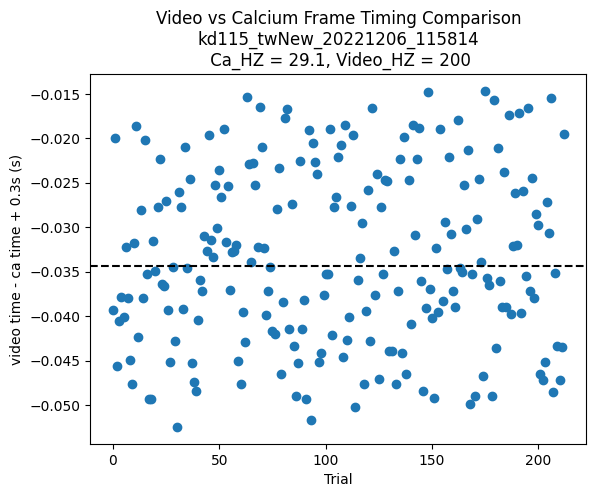

In [144]:
video_hz = 200
ca_hz = 29.1
plt.plot(video_frames_per_trial/video_hz - ca_n_frames/ca_hz + 0.3,'o')
plt.axhline(-1/ca_hz, color = 'k', linestyle = '--')
plt.xlabel('Trial')
plt.ylabel('video time - ca time + 0.3s (s)')
plt.title('Video vs Calcium Frame Timing Comparison\n%s\n Ca_HZ = 29.1, Video_HZ = 200' % sess)
plt.savefig(figfolder + '%s_video_vs_ca_timing_comparison.png' % sess, dpi=300)

In [18]:
bpod_data[0].shape

(21, 459)

In [17]:
bpod_data[2][14]

['kd115_side_trial15_date_2022_12_06_time_12_11_00.mp4',
 'kd115_bottom_trial15_date_2022_12_06_time_12_11_00.mp4',
 'kd115_body_trial15_date_2022_12_06_time_12_11_00.mp4']